# TA3 - Fine-Tuning a Hugging Face Foundation Model on FashionMNIST (Manual PyTorch, No Lightning)

This notebook implements the full training loop manually (no PyTorch Lightning), including deterministic split, train-only normalization statistics, checkpointing (`best.pt` + `last.pt`), resume support, and final persistence/export.

## Imports and Setup

In [1]:
import json
import os
import random
import time
from pathlib import Path
from typing import Any

os.environ['HF_HUB_DISABLE_XET'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torchinfo import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from transformers import AutoImageProcessor, AutoModelForImageClassification

import onnx
import onnxruntime as ort

from plot_utils import plot_random_raw_samples, plot_one_per_class, plot_confusion_matrix

In [2]:
SEED = 2711775712

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_built() and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

Using device: mps


In [ ]:
DATA_ROOT = Path('../data')
ARTIFACT_DIR = Path('./artifacts_ta3_ft_test')
CKPT_DIR = ARTIFACT_DIR / 'checkpoints'
FINAL_HF_DIR = ARTIFACT_DIR / 'final_hf'
ONNX_DIR = ARTIFACT_DIR / 'onnx'

for p in [ARTIFACT_DIR, CKPT_DIR, FINAL_HF_DIR, ONNX_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CHECKPOINT_BEST_PATH = CKPT_DIR / 'best.pt'
CHECKPOINT_LAST_PATH = CKPT_DIR / 'last.pt'

MODEL_NAME = 'google/vit-base-patch16-224-in21k'
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
NUM_CLASSES = len(CLASS_NAMES)

WARMUP_EPOCHS = 5
VAL_RATIO = 0.10
BATCH_SIZE = 512
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_METRIC = 'accuracy'  # 'accuracy' or 'loss'
RESUME = True

NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = (DEVICE.type == 'cuda')
AMP_ENABLED = (DEVICE.type == 'cuda')

print(f'Model: {MODEL_NAME}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {MAX_EPOCHS}')
print(f'Artifacts dir: {ARTIFACT_DIR.resolve()}')
print(f'AMP enabled: {AMP_ENABLED}')

Model: google/vit-base-patch16-224-in21k
Batch size: 512
Epochs: 50
Artifacts dir: /Users/guillem/Documents/DL_TA_Sessions/session_3/artifacts_ta3_ft_test
AMP enabled: False


## Checkpoint Strategy (Raw PyTorch)

We use **full `.pt` checkpoints** and keep only:
- `best.pt`: highest validation (multiclass) accuracy so far.
- `last.pt`: latest finished epoch.

### Other common options
- Only saving `model.state_dict()`: smaller, but no optimizer/scheduler/scaler/RNG resume.
- Only saving `save_pretrained()`: good for inference sharing, weak for exact training resume.

## Data Loading and Raw Data Exploration

In [4]:
raw_train = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=True, transform=None)
raw_test = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=None)

print(f'Train size: {len(raw_train):,}')
print(f'Test size: {len(raw_test):,}')
print(f'Raw image size: {raw_train[0][0].size} (grayscale)')
print(f'Classes in dataset: {len(raw_train.classes)}')

Train size: 60,000
Test size: 10,000
Raw image size: (28, 28) (grayscale)
Classes in dataset: 10


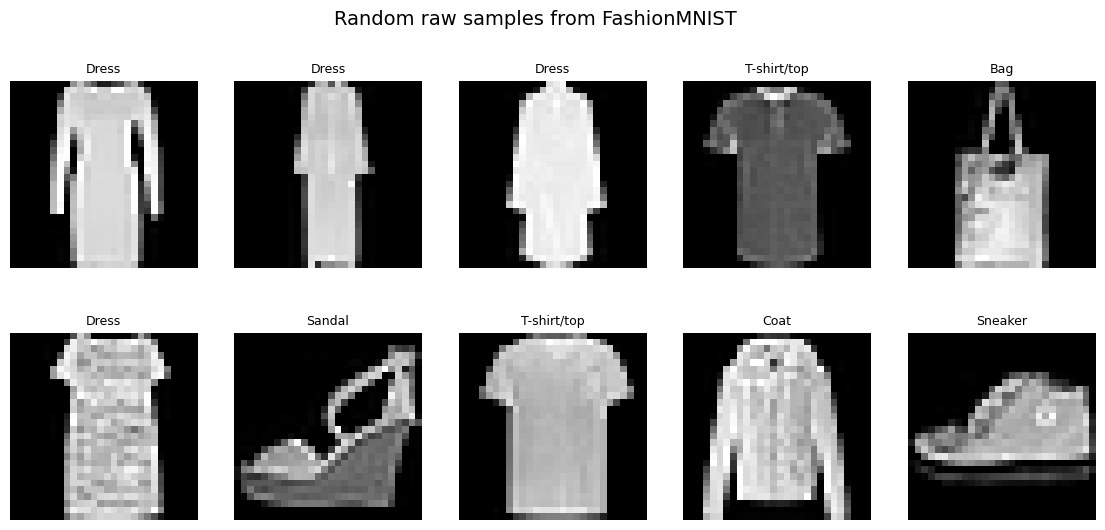

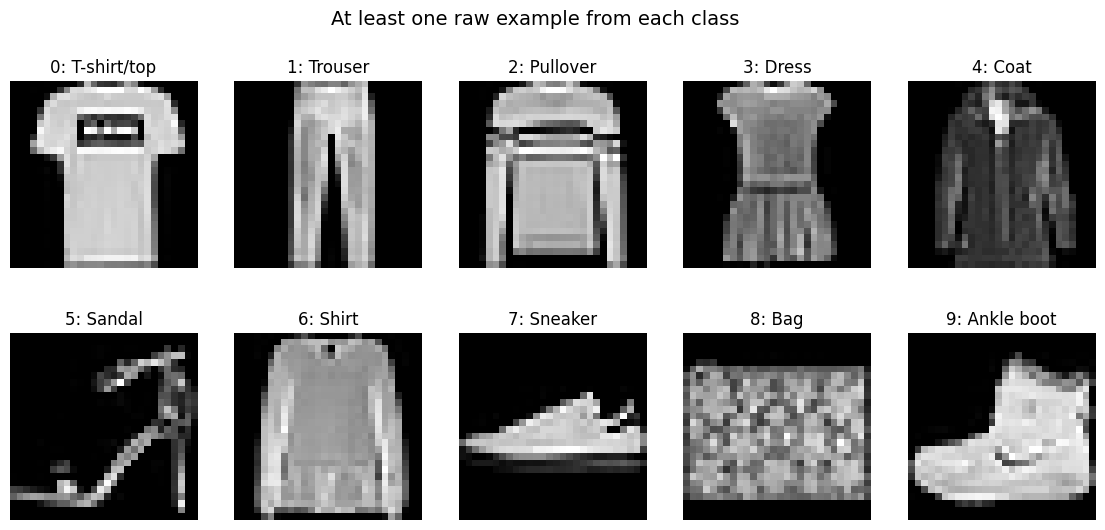

In [5]:
plot_random_raw_samples(raw_train, CLASS_NAMES, n=10, seed=SEED)
plot_one_per_class(raw_train, CLASS_NAMES)

## Deterministic Train/Validation Split and Normalization Stats

Important: mean/std are computed **only from the train split** (not val/test), using the exact deterministic split indices.

In [6]:
train_targets = raw_train.targets.numpy()
all_indices = np.arange(len(train_targets))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_targets,
    shuffle=True,
)

print(f'Train subset size: {len(train_idx):,}')
print(f'Validation subset size: {len(val_idx):,}')

Train subset size: 54,000
Validation subset size: 6,000


In [7]:
train_pixels = raw_train.data[train_idx].float() / 255.0
train_mean_scalar = float(train_pixels.mean().item())
train_std_scalar = float(train_pixels.std(unbiased=False).item())

# FashionMNIST is grayscale; after channel replication to RGB we use the same stats per channel.
IMAGE_MEAN = [train_mean_scalar] * 3
IMAGE_STD = [max(train_std_scalar, 1e-8)] * 3

print(f'Train mean (grayscale): {train_mean_scalar:.6f}')
print(f'Train std  (grayscale): {train_std_scalar:.6f}')
print(f'Applied RGB mean: {IMAGE_MEAN}')
print(f'Applied RGB std: {IMAGE_STD}')

Train mean (grayscale): 0.285947
Train std  (grayscale): 0.353023
Applied RGB mean: [0.2859467566013336, 0.2859467566013336, 0.2859467566013336]
Applied RGB std: [0.35302332043647766, 0.35302332043647766, 0.35302332043647766]


## Processor, Transforms, and DataLoaders

We adapt FashionMNIST from `1x28x28` to `3x224x224`.

In [8]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast=True)

if isinstance(processor.size, dict):
    if 'height' in processor.size and 'width' in processor.size:
        IMG_HEIGHT = int(processor.size['height'])
        IMG_WIDTH = int(processor.size['width'])
    elif 'shortest_edge' in processor.size:
        IMG_HEIGHT = IMG_WIDTH = int(processor.size['shortest_edge'])
    else:
        IMG_HEIGHT = IMG_WIDTH = 224
else:
    IMG_HEIGHT = IMG_WIDTH = int(processor.size)

print(f'Processor size field: {processor.size}')
print(f'Model input size used: {(IMG_HEIGHT, IMG_WIDTH)}')
print(f'Processor mean/std (reference): {processor.image_mean} / {processor.image_std}')
print(f'Dataset train-only mean/std (used): {IMAGE_MEAN} / {IMAGE_STD}')

train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=InterpolationMode.BICUBIC), # Resize can be expensive so we do it on a single channel, before channel replication.
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Grayscale(num_output_channels=3), # Grayscale operates on PIL images, so it must come before ToTensor.
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

Processor size field: {'height': 224, 'width': 224}
Model input size used: (224, 224)
Processor mean/std (reference): [0.5, 0.5, 0.5] / [0.5, 0.5, 0.5]
Dataset train-only mean/std (used): [0.2859467566013336, 0.2859467566013336, 0.2859467566013336] / [0.35302332043647766, 0.35302332043647766, 0.35302332043647766]


In [9]:
train_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=False, transform=train_transform)
val_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=False, transform=eval_transform)
test_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=False, transform=eval_transform)

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

def make_dataloader(ds, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

train_loader = make_dataloader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_dataloader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_example, y_example = next(iter(train_loader))
print('Batch X shape:', tuple(x_example.shape))
print('Batch y shape:', tuple(y_example.shape))
print('Label min/max:', int(y_example.min()), int(y_example.max()))

Batch X shape: (512, 3, 224, 224)
Batch y shape: (512,)
Label min/max: 0 9


## Load Model Once + Summary

Model is loaded exactly once and reused throughout the notebook.

In [16]:
id2label = {idx: name for idx, name in enumerate(CLASS_NAMES)}
label2id = {name: idx for idx, name in enumerate(CLASS_NAMES)}

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model = model.to(DEVICE)

print('Model loaded once and moved to device.')
print(summary(
    model,
    input_size=(1, 3, IMG_HEIGHT, IMG_WIDTH),
    device=str(DEVICE),
    depth=10, # You need to set a higher depth if you want to inspect everything inside the architecture
    mode='train'
))

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded once and moved to device.
Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [1, 10]                   --
├─ViTModel: 1-1                                         [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             --
│    │    │    └─Conv2d: 4-1                            [1, 768, 14, 14]          590,592
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [1, 197, 768]             --
│    │    └─ModuleList: 3-3                             --                        --
│    │    │    └─ViTLayer: 4-2                          [1, 197, 768]             --
│    │    │    │    └─LayerNorm: 5-1                    [1, 197, 768]             1,536
│    │  

In [11]:
# We print the full model architecture
print(model.train())

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
"""
---------- Backbone Freezing ----------

By default, ALL 85.8M parameters are trainable.  This is "full fine-tuning".
Two lighter alternatives are common in practice:

1. **Linear probing** — freeze the entire backbone; only train the classifier head.
   Fastest, but limited if the pretrained features don't match the target domain well.
2. **Partial fine-tuning** — freeze early layers, unfreeze later layers + head.
   A middle ground: adapts high-level features while preserving low-level ones.

Below we show how to implement option 1.  To use it, uncomment the loop.
To go back to full fine-tuning, simply re-run the model loading cell above (and commenting the loop out again).
"""

# --- Option 1: freeze backbone, train only the classifier head ---
# for param in model.vit.parameters():
#     param.requires_grad = False

"""
Actually, I was trying things around and decided to unfreeze the last 4 ViT layers
"""
# for param in model.vit.encoder.layer[-4:].parameters():
#     param.requires_grad = True

# --- Verify what is trainable ---

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - trainable
print(f"Total params:     {total:>12,}")
print(f"Trainable params: {trainable:>12,}")
print(f"Frozen params:    {frozen:>12,}")

Total params:       85,806,346
Trainable params:   85,806,346
Frozen params:               0


## Manual Training and Checkpoint Utilities

In [ ]:
def compute_epoch_metrics(y_true: list[int], y_pred: list[int]) -> dict[str, float]:
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
    }

def save_checkpoint(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)

def load_checkpoint(path: Path, device: torch.device) -> dict[str, Any]:
    return torch.load(path, map_location=device, weights_only=False)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
) -> dict[str, float]:
    model.train()
    losses = []
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())
        all_true.extend(y.detach().cpu().tolist())
        all_pred.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

    metrics = compute_epoch_metrics(all_true, all_pred)
    metrics['loss'] = float(np.mean(losses))
    return metrics


@torch.no_grad()
def evaluate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[dict[str, float], list[int], list[int]]:
    model.eval()
    losses = []
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)

        losses.append(loss.item())
        all_true.extend(y.detach().cpu().tolist())
        all_pred.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

    metrics = compute_epoch_metrics(all_true, all_pred)
    metrics['loss'] = float(np.mean(losses))
    return metrics, all_true, all_pred


def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
    max_epochs: int,
    early_stopping_patience: int,
    best_ckpt_path: Path,
    last_ckpt_path: Path,
    resume: bool = True,
    early_stopping_metric: str = 'accuracy',
) -> dict[str, Any]:
    start_epoch = 0
    
    higher_is_better = (early_stopping_metric == 'accuracy')
    best_metric_val = -1.0 if higher_is_better else np.inf
        
    epochs_without_improvement = 0
    history_rows: list[dict[str, float]] = []

    if resume and last_ckpt_path.exists():
        payload = load_checkpoint(last_ckpt_path, DEVICE)
        model.load_state_dict(payload['model_state_dict'])
        optimizer.load_state_dict(payload['optimizer_state_dict'])
        scheduler.load_state_dict(payload['scheduler_state_dict'])
        if payload.get('scaler_state_dict') is not None:
            scaler.load_state_dict(payload['scaler_state_dict'])

        start_epoch = int(payload['epoch'])
        best_metric_val = float(payload['best_metric_val'])
        epochs_without_improvement = int(payload['epochs_without_improvement'])
        history_rows = payload.get('history_rows', [])

        print(f"Resuming from epoch {start_epoch} with best_metric_val={best_metric_val:.4f}")

    for epoch in range(start_epoch, max_epochs):
        epoch_start = time.perf_counter()

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        
        # In production we would have a separate function to evaluate the validation splits.
        # We would have a duplicate val eval function that only returns the metrics, 
        # because we only use the metrics and discard all_pred and all_true here.
        val_metrics, _, _ = evaluate_one_epoch(model, val_loader, criterion)

        scheduler.step()

        epoch_row = {
            'epoch': epoch+1,
            'lr': optimizer.param_groups[0]['lr'],
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['accuracy'],
            'train_macro_f1': train_metrics['macro_f1'],
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
        }
        history_rows.append(epoch_row)

        current_metric = val_metrics[early_stopping_metric]
        improved = (current_metric > best_metric_val) if higher_is_better else (current_metric < best_metric_val)
        
        if improved:
            best_metric_val = current_metric
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        checkpoint_payload = {
            'epoch': epoch+1,
            'best_metric_val': best_metric_val,
            'epochs_without_improvement': epochs_without_improvement,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'history_rows': history_rows,
            'config': {
                'model_name': MODEL_NAME,
                'batch_size': BATCH_SIZE,
                'max_epochs': max_epochs,
                'lr': LR,
                'weight_decay': WEIGHT_DECAY,
                'early_stopping_patience': early_stopping_patience,
                'val_ratio': VAL_RATIO,
                'seed': SEED,
            },
        }

        # Always keep only the latest checkpoint for resume.
        save_checkpoint(last_ckpt_path, checkpoint_payload)

        # Keep only one best checkpoint file (overwrite when improved).
        if improved:
            save_checkpoint(best_ckpt_path, checkpoint_payload)

        epoch_minutes = (time.perf_counter() - epoch_start) / 60.0
        print(
            f"Epoch {epoch + 1:03d}/{max_epochs:03d} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"best_metric_val={best_metric_val:.4f} | "
            f"{epoch_minutes:.2f} min"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f'Early stopping triggered (patience={early_stopping_patience}).')
            break

    history_df = pd.DataFrame(history_rows)
    return {
        'history_df': history_df,
        'best_metric_val': float(best_metric_val),
        'epochs_ran': int(len(history_rows)),
        'best_checkpoint_path': str(best_ckpt_path),
        'last_checkpoint_path': str(last_ckpt_path),
    }

## Train (Manual Loop)

In [81]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-2, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)

scaler = torch.amp.GradScaler(DEVICE.type, enabled=AMP_ENABLED)

start_time = time.perf_counter()
train_result = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    scaler=scaler,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    best_ckpt_path=CHECKPOINT_BEST_PATH,
    last_ckpt_path=CHECKPOINT_LAST_PATH,
    resume=RESUME,
    early_stopping_metric=VAL_METRIC,
)
training_minutes = (time.perf_counter() - start_time) / 60.0

print(f"Training finished in {training_minutes:.2f} minutes")
print('Best validation metric:', round(train_result['best_metric_val'], 4))
print('Epochs executed:', train_result['epochs_ran'])
print('Best checkpoint:', train_result['best_checkpoint_path'])
print('Last checkpoint:', train_result['last_checkpoint_path'])

train_result['history_df'].tail()

Epoch 001/050 | train_loss=2.2043 train_acc=0.3527 | val_loss=2.1174 val_acc=0.5877 val_macro_f1=0.5860 | best_metric_val=0.5877 | 9.58 min
Epoch 002/050 | train_loss=1.0440 train_acc=0.8450 | val_loss=0.5775 val_acc=0.9037 val_macro_f1=0.9024 | best_metric_val=0.9037 | 9.22 min
Epoch 003/050 | train_loss=0.4381 train_acc=0.9169 | val_loss=0.3440 val_acc=0.9297 val_macro_f1=0.9288 | best_metric_val=0.9297 | 9.22 min
Epoch 004/050 | train_loss=0.2998 train_acc=0.9349 | val_loss=0.2837 val_acc=0.9300 val_macro_f1=0.9273 | best_metric_val=0.9300 | 9.22 min
Epoch 005/050 | train_loss=0.2224 train_acc=0.9464 | val_loss=0.2137 val_acc=0.9412 val_macro_f1=0.9405 | best_metric_val=0.9412 | 9.22 min
Epoch 006/050 | train_loss=0.1694 train_acc=0.9566 | val_loss=0.1924 val_acc=0.9423 val_macro_f1=0.9424 | best_metric_val=0.9423 | 9.22 min
Epoch 007/050 | train_loss=0.1337 train_acc=0.9635 | val_loss=0.1801 val_acc=0.9428 val_macro_f1=0.9429 | best_metric_val=0.9428 | 9.22 min
Epoch 008/050 | trai

,epoch,lr,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1
41,41,0.000009,0.000762,1.0,1.0,0.236977,0.957667,0.957647
42,42,0.000007,0.000749,1.0,1.0,0.237485,0.957667,0.957647
43,43,0.000005,0.000739,1.0,1.0,0.237931,0.957667,0.957647
44,44,0.000004,0.000731,1.0,1.0,0.238277,0.957833,0.957814
45,45,0.000003,0.000725,1.0,1.0,0.238557,0.957833,0.957814


## Evaluate Best Checkpoint on Test Data

In [33]:
criterion = nn.CrossEntropyLoss()
best_payload = load_checkpoint(CHECKPOINT_BEST_PATH, DEVICE)
model.load_state_dict(best_payload['model_state_dict'])
model = model.to(DEVICE)

test_metrics, y_true_test, y_pred_test = evaluate_one_epoch(model, test_loader, criterion)

print('Test metrics (out-of-sample):')
print(f"  Loss:      {test_metrics['loss']:.4f}")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Macro-F1:  {test_metrics['macro_f1']:.4f}")

print('Per-class report:')
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, digits=4))

Test metrics (out-of-sample):
  Loss:      0.2688
  Accuracy:  0.9520
  Macro-F1:  0.9519
Per-class report:
              precision    recall  f1-score   support

 T-shirt/top     0.9104    0.9140    0.9122      1000
     Trouser     0.9980    0.9950    0.9965      1000
    Pullover     0.9276    0.9350    0.9313      1000
       Dress     0.9480    0.9480    0.9480      1000
        Coat     0.9279    0.9400    0.9339      1000
      Sandal     0.9930    0.9920    0.9925      1000
       Shirt     0.8678    0.8470    0.8573      1000
     Sneaker     0.9713    0.9830    0.9771      1000
         Bag     0.9940    0.9950    0.9945      1000
  Ankle boot     0.9808    0.9710    0.9759      1000

    accuracy                         0.9520     10000
   macro avg     0.9519    0.9520    0.9519     10000
weighted avg     0.9519    0.9520    0.9519     10000



High 0.94s (like 0.947 or 0.948) is a way more realistic expectation in this dataset. This 0.952 run took 424 minutes (7 hours xd) on my cloud machine (not CUDA accelerated, but it is a powerful Mac and still took that long).

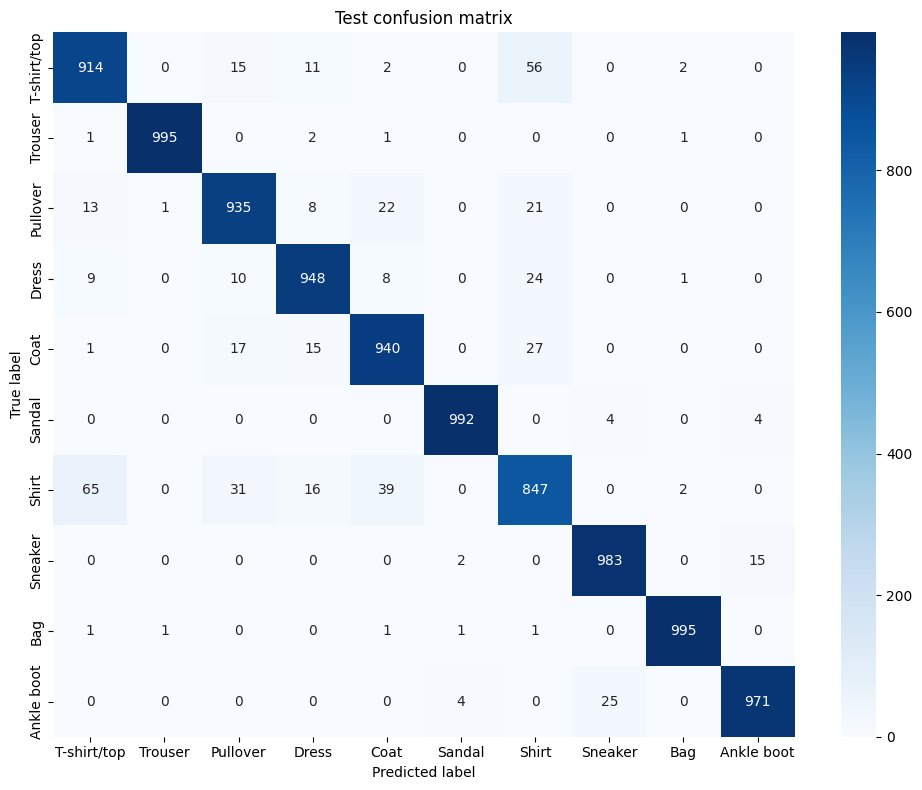

In [34]:
plot_confusion_matrix(y_true_test, y_pred_test, CLASS_NAMES)

## Save Final Hugging Face Artifacts

In [35]:
model.save_pretrained(FINAL_HF_DIR)
processor.save_pretrained(FINAL_HF_DIR)
(FINAL_HF_DIR / 'class_names.json').write_text(json.dumps(CLASS_NAMES, indent=2))

print(f'Saved Hugging Face model + processor to: {FINAL_HF_DIR.resolve()}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Hugging Face model + processor to: /Users/guillem/Documents/DL_TA_Sessions/session_3/artifacts_ta3_ft_test/final_hf


## Optional ONNX Export (from Best Weights)

In [36]:
class HFLogitsWrapper(nn.Module):
    def __init__(self, hf_model: nn.Module):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return self.hf_model(pixel_values=pixel_values).logits


onnx_path = ONNX_DIR / 'fashionmnist_vit_best.onnx'
export_wrapper = HFLogitsWrapper(model).cpu().eval() # BEWARE: this moves the model back to CPU
dummy_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH, dtype=torch.float32)

batch_dim = torch.export.Dim("batch_size", min=1, max=512)

torch.onnx.export(
    export_wrapper,
    (dummy_input,),
    str(onnx_path),
    input_names=['pixel_values'],
    output_names=['logits'],
    dynamic_shapes={"pixel_values": {0: batch_dim}},
    opset_version=18,
)

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)

print(f'ONNX model exported and validated at: {onnx_path.resolve()}')

W0309 18:08:33.061000 60006 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0309 18:08:33.062000 60006 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0309 18:08:33.063000 60006 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0309 18:08:33.063000 60006 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `HFLogitsWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HFLogitsWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/guillem/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 50 of general pattern rewrite rules.
ONNX model exported and validated at: /Users/guillem/Documents/DL_TA_Sessions/session_3/artifacts_ta3_ft_test/onnx/fashionmnist_vit_best.onnx


In [37]:
ort_session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])

x_batch, _ = next(iter(test_loader))
x_sample = x_batch[:16].cpu()

with torch.no_grad():
    torch_logits = export_wrapper(x_sample).numpy()

ort_logits = ort_session.run(['logits'], {'pixel_values': x_sample.numpy()})[0]

torch_pred = torch_logits.argmax(axis=1)
ort_pred = ort_logits.argmax(axis=1)
agreement = (torch_pred == ort_pred).mean()

print(f'PyTorch logits shape: {torch_logits.shape}')
print(f'ONNX logits shape: {ort_logits.shape}')
print(f'Top-1 agreement on sample batch: {agreement:.4f}')

PyTorch logits shape: (16, 10)
ONNX logits shape: (16, 10)
Top-1 agreement on sample batch: 1.0000
